---
title: "Turbofan remaining life: TabPFN 3 vs 3.5"
description: "Compare RUL point predictions across NASA C-MAPSS FD001–FD004."
cookbookTags:
  - regression
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

An engine can keep running while its sensors reveal signs of wear, making the timing of maintenance a prediction problem. Here we estimate how many operating cycles remain before failure from sensor readings and operating settings in NASA’s simulated turbofan degradation data. Useful remaining-life estimates could help maintenance teams plan inspections and replacements before an unexpected shutdown, while avoiding premature replacement.

## Setup

Install the dependencies in a fresh Python kernel. Compare TabPFN 3 and 3.5 with standard inference and high thinking effort. Timings include network and queue latency. Set `thinking_metric="mean_absolute_error"` so thinking optimizes the same metric shown in the results.

Authenticate using the [quickstart](https://docs.priorlabs.ai/cookbook/quickstart), or set `TABPFN_TOKEN` in your local environment before running the notebook.

In [ ]:
%pip install -q --upgrade tabpfn-client "pandas==2.3.3" "numpy==2.4.6" "scikit-learn==1.9.0" "matplotlib==3.11.1"

In [1]:
import time
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tabpfn_client import TabPFNRegressor
from tabpfn_client.api_models import ModelVersion
from tabpfn_client.models import ApiMode

VERSIONS = {"TabPFN 3": ModelVersion.V3, "TabPFN 3.5": ModelVersion.V3_5}
VARIANTS = [(name, thinking) for name in VERSIONS for thinking in (False, True)]
plt.rcParams.update({"figure.figsize": (7, 3.5), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 120})

def archive(url):
    return ZipFile(BytesIO(urlopen(url).read()))

The helpers below keep model settings and chart colors consistent across variants.

The client documents [`mean_absolute_error`](https://github.com/PriorLabs/tabpfn-client/blob/v0.6.0/src/tabpfn_client/estimator.py#L684-L696) as a supported regression thinking objective; `mae` is an alias for the same metric.

In [2]:
def model_for(cls, name, thinking=False, **kwargs):
    return cls.create_default_for_version(
        VERSIONS[name], n_estimators=4, random_state=42,
        api_mode=ApiMode.ASYNC if thinking else ApiMode.AUTO,
        thinking_effort="high" if thinking else None,
        thinking_metric="mean_absolute_error" if thinking else None, **kwargs,
    )

def performance_bars(results, metric, direction):
    colors = {"TabPFN 3": "#90a4ae", "TabPFN 3 + thinking high": "#5c6bc0",
              "TabPFN 3.5": "#80cbc4", "TabPFN 3.5 + thinking high": "#00897b",
              "XGBoost": "#bcaaa4"}
    values = results[metric].iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(values.index, values, color=[colors[name] for name in values.index])
    ax.set(xlabel=f"{metric} ({direction} is better)", ylabel="")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    low, high = values.min(), values.max()
    if low > 0 and high - low < 0.2 * high:
        padding = max((high - low) * 0.3, high * 0.01, 0.001)
        ax.set_xlim(max(0, low - padding), high + 2 * padding)
        ax.set_title("Zoomed axis (does not start at zero)", fontsize=9)
    else:
        ax.set_xlim(0, high * 1.22)
    fig.tight_layout()
    plt.show()


## Data and split

Use [NASA C-MAPSS](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/), downloaded from the [archive used by NASA's loader](https://github.com/nasa/progpy/blob/master/src/progpy/datasets/nasa_cmapss.py). Fit one model per FD subset. Training RUL is each engine's final cycle minus its current cycle; score the last observed cycle of each official test engine against the supplied RUL file, without capping the target.

Sample at most 5,000 training cycles per subset for a compact API example. Engine IDs are categorical and **namespaced by split**: `train:1` and `test:1` are different engines. Every test engine is unseen during fitting.

In [3]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
cols = ["engine", "cycle"] + [f"setting_{i}" for i in range(1, 4)] + [f"sensor_{i}" for i in range(1, 22)]
datasets = {}
with archive("https://zenodo.org/records/15346912/files/CMAPSSData.zip?download=1") as z:
    for subset in ["FD001", "FD002", "FD003", "FD004"]:
        train = pd.read_csv(z.open(f"train_{subset}.txt"), sep=r"\s+", names=cols)
        test = pd.read_csv(z.open(f"test_{subset}.txt"), sep=r"\s+", names=cols)
        train["RUL"] = train.groupby("engine")["cycle"].transform("max") - train["cycle"]
        train = train.sample(n=min(5000, len(train)), random_state=42)
        test = test.sort_values(["engine", "cycle"]).groupby("engine", sort=True).tail(1)
        y_test = np.loadtxt(z.open(f"RUL_{subset}.txt"))
        train["engine"] = "train:" + train["engine"].astype(str)
        test["engine"] = "test:" + test["engine"].astype(str)
        assert not set(train.engine) & set(test.engine)
        assert len(test) == len(y_test)
        datasets[subset] = (train[cols], train.RUL.to_numpy(), test[cols], y_test)
display(pd.DataFrame([{"Subset": s, "Train cycles": len(d[0]), "Test engines": len(d[2])}
                      for s, d in datasets.items()]).set_index("Subset"))

,Train cycles,Test engines
Subset,,
FD001,5000,100
FD002,5000,259
FD003,5000,100
FD004,5000,248


## Compare

Use point predictions for all four variants so standard and thinking modes share the same task. Clip negative remaining-life predictions to zero. **MAE**, measured in engine cycles, is both the thinking objective and the displayed performance metric. Average each metric equally across the four FD subsets.

In [4]:
rows, predictions = [], {}
for subset, (X_train, y_train, X_test, y_test) in datasets.items():
    for name, thinking in VARIANTS:
        label = name + (" + thinking high" if thinking else "")
        start = time.perf_counter()
        model = model_for(TabPFNRegressor, name, thinking, categorical_features_indices=[0])
        model.fit(X_train, y_train)
        p = np.maximum(0, np.asarray(model.predict(X_test)).reshape(-1))
        assert p.shape == y_test.shape
        predictions[subset, label] = p
        rows.append({"Subset": subset, "Model": label,
                     "MAE": mean_absolute_error(y_test, p),
                     "RMSE": root_mean_squared_error(y_test, p),
                     "Seconds": time.perf_counter() - start})
        print(f"Finished {subset}: {label}")
per_subset = pd.DataFrame(rows)
all_results = per_subset.groupby("Model", sort=False).mean(numeric_only=True)

Train set already exists, skipping upload.


Test set already exists, skipping upload.


Train set already exists, skipping upload.


Finished FD001: TabPFN 3


Test set already exists, skipping upload.


...

Test set already exists, skipping upload.


Train set already exists, skipping upload.


Finished FD004: TabPFN 3.5


Test set already exists, skipping upload.


Finished FD004: TabPFN 3.5 + thinking high


## Results

Averaged equally across the four scenarios, TabPFN 3.5 lowers MAE from 28.21 to 24.74 cycles compared with v3. Thinking optimized for MAE lowers average error further, to 27.98 cycles for v3 and 23.36 for v3.5. The subset table shows that v3.5 thinking improves FD001 and FD003 but increases error on FD002 and FD004.

,MAE
Model,
TabPFN 3,28.2118
TabPFN 3 + thinking high,27.9847
TabPFN 3.5,24.7402
TabPFN 3.5 + thinking high,23.3577


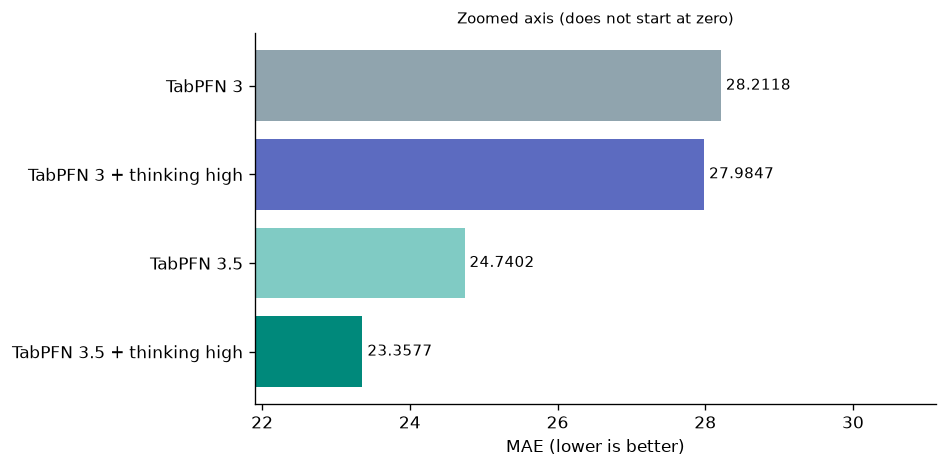

In [5]:
display(all_results[["MAE"]].round(4))
performance_bars(all_results, "MAE", "lower")

In [6]:
display(per_subset.pivot(index="Subset", columns="Model", values="MAE").round(3))

Model,TabPFN 3,TabPFN 3 + thinking high,TabPFN 3.5,TabPFN 3.5 + thinking high
Subset,,,,
FD001,24.032,26.907,23.258,19.841
FD002,29.244,28.545,23.327,24.341
FD003,29.693,25.504,24.310,19.773
FD004,29.878,30.983,28.066,29.476


### What to take away

TabPFN 3.5 with thinking reduces average remaining-life error by about 17% relative to standard v3. The benefit depends on the operating scenario, so inspect the subset results before applying the overall conclusion to maintenance planning.